In [28]:
!pip install scipy

# 2. Kiểm định giả thuyết

Kiểm định các giả thuyết nghiên cứu trên tập dữ liệu **Wine Quality Red**.

Mỗi cặp gồm **giả thuyết không (H)** và **giả thuyết đối (H')**. Nếu p-value < α thì **bác bỏ H'** và **chấp nhận H**.

**Mức ý nghĩa:** α = 0,05 cho tất cả kiểm định.

### Các giả thuyết nghiên cứu (H)

| Mã | Nội dung |
|----|----------|
| **H0** | Nồng độ cồn trung bình có thay đổi đáng kể theo điểm chất lượng chủ quan |
| **H1** | Hàm lượng cồn **không** có mối liên hệ tích cực đáng kể với chất lượng |
| **H2** | Độ axit bay hơi cao **không** ảnh hưởng tiêu cực đến chất lượng của rượu vang đỏ |

### Các giả thuyết đối (H')

| Mã | Nội dung |
|----|----------|
| **H'0** | Nồng độ cồn trung bình **không** thay đổi đáng kể theo điểm chất lượng |
| **H'1** | Rượu cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn |
| **H'2** | Độ axit bay hơi **có** ảnh hưởng đáng kể đến chất lượng của rượu vang đỏ |

## 2.1. Phương pháp kiểm định

| Mã | H (nghiên cứu) | H' (đối / H₀) | Phương pháp | Điều kiện áp dụng | α |
|----|----------------|---------------|-------------|-------------------|---|
| **H0** | Alcohol khác biệt theo quality | Không khác biệt | **Kruskal-Wallis** (so sánh nhiều nhóm độc lập dựa trên thứ hạng) | Các quan sát độc lập; ≥ 2 nhóm theo `quality`; không yêu cầu phân phối chuẩn hay phương sai đồng nhất | 0,05 (hai phía) |
| **H1** | μ_cồn(nhóm cao) ≤ μ_cồn(nhóm thấp) | Cồn cao → quality tốt hơn | **Welch t-test** hai mẫu độc lập (một phía); dự phòng **Wilcoxon rank-sum** | Gom nhóm: quality ≥ 6 (cao) vs ≤ 5 (thấp); không yêu cầu phương sai đồng nhất | 0,05 (một phía) |
| **H2** | μ_axit(nhóm cao) ≥ μ_axit(nhóm thấp) | Axit có ảnh hưởng đáng kể đến quality | **Welch t-test** hai mẫu độc lập (một phía); dự phòng **Wilcoxon rank-sum** | Gom nhóm: quality ≥ 6 (cao) vs ≤ 5 (thấp); không yêu cầu phương sai đồng nhất | 0,05 (một phía) |

In [29]:
import importlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import hypothesis_testing
importlib.reload(hypothesis_testing)
from hypothesis_testing import hypothesis_test

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

ALPHA = 0.05
DATA_PATH = Path("dataset/winequality-red.csv")
df = pd.read_csv(DATA_PATH)

## 2.2. Kiểm định H0 / H'0 — Kruskal-Wallis

**Giả thuyết nghiên cứu (H0):** Nồng độ cồn trung bình không thay đổi đáng kể theo điểm chất lượng chủ quan.

**Giả thuyết đối (H'0):** Nồng độ cồn trung bình **có** thay đổi đáng kể theo điểm chất lượng.

**Phương pháp:** Kruskal-Wallis (phi tham số, so sánh nhiều nhóm độc lập dựa trên thứ hạng).

Trong đó: **H** là thống kê Kruskal-Wallis; **k** là số nhóm (số mức `quality`); bậc tự do **k − 1**.

**Bác bỏ H'0 khi và chỉ khi:**

$$H > \chi^2_{\alpha;\, k-1}$$

(tương đương **p-value < α**). Khi đó **chấp nhận H0**.

**Mức ý nghĩa:** α = 0,05.

,Số mẫu,Trung bình,Trung vị,Độ lệch chuẩn
quality,,,,
3,10,9.955000,9.925,0.818009
4,53,10.265094,10.000,0.934776
5,681,9.899706,9.700,0.736521
6,638,10.629519,10.500,1.049639
7,199,11.465913,11.500,0.961933
8,18,12.094444,12.150,1.224011


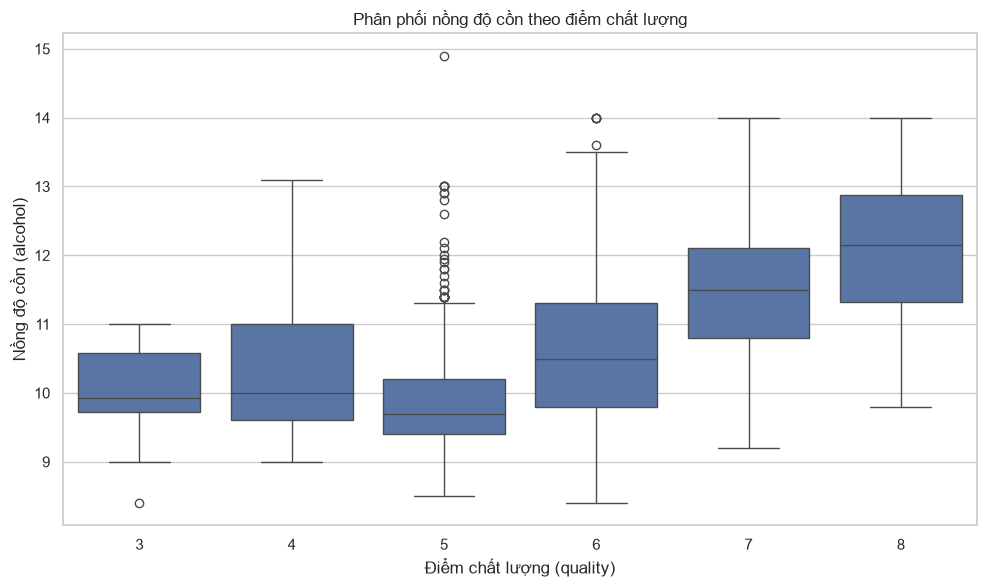

In [30]:
# Thống kê mô tả alcohol theo từng mức quality
alcohol_by_quality = (
    df.groupby("quality")["alcohol"]
    .agg(["count", "mean", "median", "std"])
    .rename(columns={
        "count": "Số mẫu",
        "mean": "Trung bình",
        "median": "Trung vị",
        "std": "Độ lệch chuẩn",
    })
)
display(alcohol_by_quality)

fig, ax = plt.subplots()
sns.boxplot(data=df, x="quality", y="alcohol", ax=ax)
ax.set_xlabel("Điểm chất lượng (quality)")
ax.set_ylabel("Nồng độ cồn (alcohol)")
ax.set_title("Phân phối nồng độ cồn theo điểm chất lượng")
plt.tight_layout()
plt.show()

In [31]:
# Kruskal-Wallis: so sánh alcohol giữa các nhóm quality
quality_levels = sorted(df["quality"].unique())
groups = [df.loc[df["quality"] == q, "alcohol"].values for q in quality_levels]

result_h0 = hypothesis_test(
    "kruskal_wallis", alternative="greater", groups=groups, alpha=ALPHA
)

H0 = "Nồng độ cồn trung bình không có thay đổi đáng kể theo điểm chất lượng chủ quan."
H0_prime = "Nồng độ cồn trung bình có thay đổi đáng kể theo điểm chất lượng."

print("=== Kiểm định Kruskal-Wallis: H0 / H'0 ===")
print(f"Số nhóm k = {result_h0['k']} (quality: {quality_levels})")
print(f"Bậc tự do k - 1 = {result_h0['df']}")
print(f"Thống kê {result_h0['statistic_name']} = {result_h0['statistic']:.4f}")
print(
    f"Giá trị tới hạn χ²_{{α; k-1}} = χ²_{{{ALPHA}; {result_h0['df']}}} "
    f"= {result_h0['critical_value']:.4f}"
)
print(f"p-value = {result_h0['p_value']:.6f}")
print(f"Mức ý nghĩa α = {ALPHA}")

reject = result_h0["p_value"] < ALPHA
print(
    f"\nH > χ²_{{α; k-1}} ?  {result_h0['statistic']:.4f} > "
    f"{result_h0['critical_value']:.4f} → {result_h0['statistic'] > result_h0['critical_value']}"
)

if reject:
    print("\nKết luận: Bác bỏ H0, chấp nhận H'0.")
    print(f"→ {H0_prime}")
else:
    print("\nKết luận: Không bác bỏ H0.")
    print(f"→ {H0}")

=== Kiểm định Kruskal-Wallis: H0 / H'0 ===
Số nhóm k = 6 (quality: [np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)])
Bậc tự do k - 1 = 5
Thống kê H = 412.3768
Giá trị tới hạn χ²_{α; k-1} = χ²_{0.05; 5} = 11.0705
p-value = 0.000000
Mức ý nghĩa α = 0.05

H > χ²_{α; k-1} ?  412.3768 > 11.0705 → True

Kết luận: Bác bỏ H0, chấp nhận H'0.
→ Nồng độ cồn trung bình có thay đổi đáng kể theo điểm chất lượng.


## 2.3. Kiểm định H1 / H'1 — Welch t-test hai mẫu độc lập (một phía)

**Giả thuyết không (H1):** Hàm lượng cồn **không** có mối liên hệ tích cực đáng kể với chất lượng.

→ $\mu_{\text{cồn}}(\text{nhóm cao}) - \mu_{\text{cồn}}(\text{nhóm thấp}) \leq 0$

**Giả thuyết thay thế (H'1):** Rượu có hàm lượng cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn.

→ $\mu_{\text{cồn}}(\text{nhóm cao}) - \mu_{\text{cồn}}(\text{nhóm thấp}) > 0$

**Phương pháp:** Welch t-test hai mẫu độc lập (một phía, **không giả định phương sai bằng nhau**); dự phòng Wilcoxon rank-sum.

**Gom nhóm:**

| Nhóm | Tiêu chí | Mức quality gốc |
|------|----------|-----------------|
| Quality cao | `quality` ≥ 6 | 6, 7, 8 |
| Quality thấp | `quality` ≤ 5 | 3, 4, 5 |

**Bác bỏ H1 khi:** p-value < α → chấp nhận H'1.

**Mức ý nghĩa:** α = 0,05.

=== Gom nhóm theo quality ===


,Số mẫu,Nhóm gom
quality,,
3,10,Quality thấp (≤5)
4,53,Quality thấp (≤5)
5,681,Quality thấp (≤5)
6,638,Quality cao (≥6)
7,199,Quality cao (≥6)
8,18,Quality cao (≥6)



=== Thống kê mô tả nồng độ cồn theo nhóm gom ===


,Số mẫu,Trung bình,Trung vị,Độ lệch chuẩn,Phương sai
nhóm quality,,,,,
Quality cao (≥6),855,10.855029,10.8,1.106109,1.223478
Quality thấp (≤5),744,9.926478,9.7,0.758007,0.574574


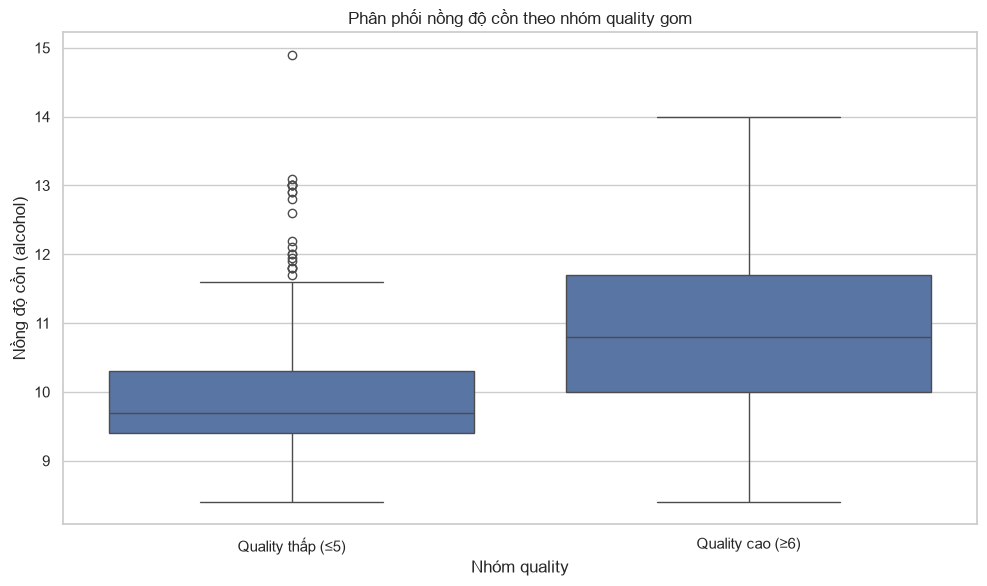


=== Phương sai hai nhóm (Welch không giả định σ₁ = σ₂) ===
Quality cao (≥6):  s² = 1.2235,  s = 1.1061
Quality thấp (≤5): s² = 0.5746,  s = 0.7580

=== Kiểm định Welch t hai mẫu độc lập: H1 / H'1 ===
Thống kê T = 19.7822
Bậc tự do Welch df = 1516.75
Giá trị tới hạn = 1.6459
p-value = 0.000000
Mức ý nghĩa α = 0.05

Bác bỏ H1 ? → True

=== Kiểm định Wilcoxon rank-sum ===
Phương pháp: mẫu lớn (n1=855, n2=744 > 10) → xấp xỉ Z
Thống kê U = 481313.0000
μ_U = 318060.0000,  σ_U = 9209.5603
Z = (U - μ_U) / σ_U = 17.7265
|Z| > Z_α ?  |17.7265| > 1.6449 → True
p-value = 0.000000
Bác bỏ H1 ? → True

Kết luận: Bác bỏ H1, chấp nhận H'1.
→ Rượu có hàm lượng cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn.


In [32]:
# Gom nhóm quality cao / thấp
df_h1 = df.copy()
df_h1["nhóm quality"] = np.where(
    df_h1["quality"] >= 6, "Quality cao (≥6)", "Quality thấp (≤5)"
)

# Ánh xạ từng mức quality → nhóm gom
quality_to_group = (
    df.groupby("quality")
    .size()
    .rename("Số mẫu")
    .to_frame()
    .assign(
        **{
            "Nhóm gom": lambda x: x.index.map(
                lambda q: "Quality cao (≥6)" if q >= 6 else "Quality thấp (≤5)"
            )
        }
    )
)
print("=== Gom nhóm theo quality ===")
display(quality_to_group)

# Thống kê mô tả alcohol theo nhóm gom
alcohol_by_group = (
    df_h1.groupby("nhóm quality")["alcohol"]
    .agg(["count", "mean", "median", "std", "var"])
    .rename(
        columns={
            "count": "Số mẫu",
            "mean": "Trung bình",
            "median": "Trung vị",
            "std": "Độ lệch chuẩn",
            "var": "Phương sai",
        }
    )
)
print("\n=== Thống kê mô tả nồng độ cồn theo nhóm gom ===")
display(alcohol_by_group)

fig, ax = plt.subplots()
sns.boxplot(data=df_h1, x="nhóm quality", y="alcohol", order=["Quality thấp (≤5)", "Quality cao (≥6)"], ax=ax)
ax.set_xlabel("Nhóm quality")
ax.set_ylabel("Nồng độ cồn (alcohol)")
ax.set_title("Phân phối nồng độ cồn theo nhóm quality gom")
plt.tight_layout()
plt.show()

high_q = df_h1.loc[df_h1["quality"] >= 6, "alcohol"]
low_q = df_h1.loc[df_h1["quality"] <= 5, "alcohol"]

s1 = high_q.std(ddof=1)
s2 = low_q.std(ddof=1)
print("\n=== Phương sai hai nhóm (Welch không giả định σ₁ = σ₂) ===")
print(f"Quality cao (≥6):  s² = {s1**2:.4f},  s = {s1:.4f}")
print(f"Quality thấp (≤5): s² = {s2**2:.4f},  s = {s2:.4f}")

H1 = "Hàm lượng cồn không có mối liên hệ tích cực đáng kể với chất lượng."
H1_prime = "Rượu có hàm lượng cồn cao hơn có xu hướng được đánh giá chất lượng tốt hơn."

# Welch t-test hai mẫu độc lập (một phía: μ_cao > μ_thấp, bác bỏ H1 nếu p < α)
result_h1_t = hypothesis_test(
    "t_two_means_welch",
    x1=high_q.mean(),
    x2=low_q.mean(),
    s1=s1,
    s2=s2,
    n1=len(high_q),
    n2=len(low_q),
    alpha=ALPHA,
    alternative="greater",
)

print("\n=== Kiểm định Welch t hai mẫu độc lập: H1 / H'1 ===")
print(f"Thống kê {result_h1_t['statistic_name']} = {result_h1_t['statistic']:.4f}")
print(f"Bậc tự do Welch df = {result_h1_t['df']:.2f}")
print(f"Giá trị tới hạn = {result_h1_t['critical_value']:.4f}")
print(f"p-value = {result_h1_t['p_value']:.6f}")
print(f"Mức ý nghĩa α = {ALPHA}")

reject = result_h1_t["p_value"] < ALPHA
print(f"\nBác bỏ H1 ? → {reject}")

# Dự phòng phi tham số: Wilcoxon rank-sum
result_h1_w = hypothesis_test(
    "wilcoxon_rank_sum",
    sample1=high_q.values,
    sample2=low_q.values,
    alpha=ALPHA,
    alternative="greater",
)

print("\n=== Kiểm định Wilcoxon rank-sum ===")
w = result_h1_w
if w["use_z_approx"]:
    print(f"Phương pháp: mẫu lớn (n1={w['n1']}, n2={w['n2']} > 10) → xấp xỉ Z")
else:
    print(f"Phương pháp: mẫu nhỏ (n1={w['n1']}, n2={w['n2']} ≤ 10) → tra bảng U / p-value chính xác")
print(f"Thống kê U = {w['statistic']:.4f}")
if w["use_z_approx"]:
    print(f"μ_U = {w['mu_u']:.4f},  σ_U = {w['sigma_u']:.4f}")
    print(f"Z = (U - μ_U) / σ_U = {w['z']:.4f}")
    print(f"|Z| > Z_α ?  |{w['z']:.4f}| > {w['critical_value']:.4f} → {abs(w['z']) > w['critical_value']}")
print(f"p-value = {w['p_value']:.6f}")
print(f"Bác bỏ H1 ? → {w['reject_h0']}")

if reject:
    print("\nKết luận: Bác bỏ H1, chấp nhận H'1.")
    print(f"→ {H1_prime}")
else:
    print("\nKết luận: Không bác bỏ H1.")
    print(f"→ {H1}")

## 2.4. Kiểm định H2 / H'2 — Welch t-test hai mẫu độc lập (một phía)

**Giả thuyết không (H2):** Độ axit bay hơi cao **không** ảnh hưởng tiêu cực đến chất lượng của rượu vang đỏ.

→ $\mu_{\text{axit}}(\text{nhóm cao}) - \mu_{\text{axit}}(\text{nhóm thấp}) \geq 0$

**Giả thuyết thay thế (H'2):** Độ axit bay hơi **có** ảnh hưởng đáng kể đến chất lượng của rượu vang đỏ.

→ $\mu_{\text{axit}}(\text{nhóm cao}) - \mu_{\text{axit}}(\text{nhóm thấp}) < 0$

**Phương pháp:** Welch t-test hai mẫu độc lập (một phía, **không giả định phương sai bằng nhau**); dự phòng Wilcoxon rank-sum.

**Gom nhóm:**

| Nhóm | Tiêu chí | Mức quality gốc |
|------|----------|-----------------|
| Quality cao | `quality` ≥ 6 | 6, 7, 8 |
| Quality thấp | `quality` ≤ 5 | 3, 4, 5 |

**Bác bỏ H2 khi:** p-value < α → chấp nhận H'2.

**Mức ý nghĩa:** α = 0,05.

=== Thống kê mô tả độ axit bay hơi theo nhóm gom ===


,Số mẫu,Trung bình,Trung vị,Độ lệch chuẩn,Phương sai
nhóm quality,,,,,
Quality cao (≥6),855,0.474146,0.46,0.161999,0.026244
Quality thấp (≤5),744,0.589503,0.59,0.177956,0.031668


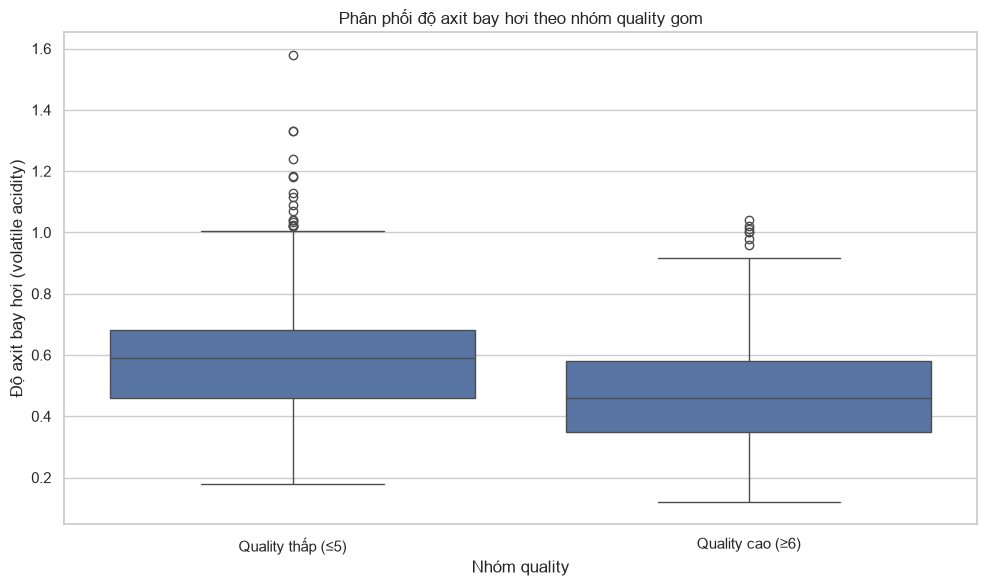


=== Phương sai hai nhóm (Welch không giả định σ₁ = σ₂) ===
Quality cao (≥6):  s² = 0.0262,  s = 0.1620
Quality thấp (≤5): s² = 0.0317,  s = 0.1780

=== Kiểm định Welch t hai mẫu độc lập: H2 / H'2 ===
Thống kê T = -13.4775
Bậc tự do Welch df = 1515.37
Giá trị tới hạn = -1.6459
p-value = 0.000000
Mức ý nghĩa α = 0.05

Bác bỏ H2 ? → True

=== Kiểm định Wilcoxon rank-sum ===
Phương pháp: mẫu lớn (n1=855, n2=744 > 10) → xấp xỉ Z
Thống kê U = 197208.0000
μ_U = 318060.0000,  σ_U = 9209.5603
Z = (U - μ_U) / σ_U = -13.1225
|Z| > Z_α ?  |-13.1225| > -1.6449 → True
p-value = 0.000000
Bác bỏ H2 ? → True

Kết luận: Bác bỏ H2, chấp nhận H'2.
→ Độ axit bay hơi có ảnh hưởng đáng kể đến chất lượng của rượu vang đỏ.


In [33]:
# Gom nhóm quality cao / thấp — biến volatile acidity
df_h2 = df.copy()
df_h2["nhóm quality"] = np.where(
    df_h2["quality"] >= 6, "Quality cao (≥6)", "Quality thấp (≤5)"
)

# Thống kê mô tả axit bay hơi theo nhóm gom
va_by_group = (
    df_h2.groupby("nhóm quality")["volatile acidity"]
    .agg(["count", "mean", "median", "std", "var"])
    .rename(
        columns={
            "count": "Số mẫu",
            "mean": "Trung bình",
            "median": "Trung vị",
            "std": "Độ lệch chuẩn",
            "var": "Phương sai",
        }
    )
)
print("=== Thống kê mô tả độ axit bay hơi theo nhóm gom ===")
display(va_by_group)

fig, ax = plt.subplots()
sns.boxplot(
    data=df_h2,
    x="nhóm quality",
    y="volatile acidity",
    order=["Quality thấp (≤5)", "Quality cao (≥6)"],
    ax=ax,
)
ax.set_xlabel("Nhóm quality")
ax.set_ylabel("Độ axit bay hơi (volatile acidity)")
ax.set_title("Phân phối độ axit bay hơi theo nhóm quality gom")
plt.tight_layout()
plt.show()

high_va = df_h2.loc[df_h2["quality"] >= 6, "volatile acidity"]
low_va = df_h2.loc[df_h2["quality"] <= 5, "volatile acidity"]

s1 = high_va.std(ddof=1)
s2 = low_va.std(ddof=1)
print("\n=== Phương sai hai nhóm (Welch không giả định σ₁ = σ₂) ===")
print(f"Quality cao (≥6):  s² = {s1**2:.4f},  s = {s1:.4f}")
print(f"Quality thấp (≤5): s² = {s2**2:.4f},  s = {s2:.4f}")

H2 = "Độ axit bay hơi cao không ảnh hưởng tiêu cực đến chất lượng của rượu vang đỏ."
H2_prime = "Độ axit bay hơi có ảnh hưởng đáng kể đến chất lượng của rượu vang đỏ."

# Welch t-test hai mẫu độc lập (một phía: μ_cao < μ_thấp, bác bỏ H2 nếu p < α)
result_h2_t = hypothesis_test(
    "t_two_means_welch",
    x1=high_va.mean(),
    x2=low_va.mean(),
    s1=s1,
    s2=s2,
    n1=len(high_va),
    n2=len(low_va),
    alpha=ALPHA,
    alternative="less",
)

print("\n=== Kiểm định Welch t hai mẫu độc lập: H2 / H'2 ===")
print(f"Thống kê {result_h2_t['statistic_name']} = {result_h2_t['statistic']:.4f}")
print(f"Bậc tự do Welch df = {result_h2_t['df']:.2f}")
print(f"Giá trị tới hạn = {result_h2_t['critical_value']:.4f}")
print(f"p-value = {result_h2_t['p_value']:.6f}")
print(f"Mức ý nghĩa α = {ALPHA}")

reject = result_h2_t["p_value"] < ALPHA
print(f"\nBác bỏ H2 ? → {reject}")

# Dự phòng phi tham số: Wilcoxon rank-sum
result_h2_w = hypothesis_test(
    "wilcoxon_rank_sum",
    sample1=high_va.values,
    sample2=low_va.values,
    alpha=ALPHA,
    alternative="less",
)

print("\n=== Kiểm định Wilcoxon rank-sum ===")
w = result_h2_w
if w["use_z_approx"]:
    print(f"Phương pháp: mẫu lớn (n1={w['n1']}, n2={w['n2']} > 10) → xấp xỉ Z")
else:
    print(f"Phương pháp: mẫu nhỏ (n1={w['n1']}, n2={w['n2']} ≤ 10) → tra bảng U / p-value chính xác")
print(f"Thống kê U = {w['statistic']:.4f}")
if w["use_z_approx"]:
    print(f"μ_U = {w['mu_u']:.4f},  σ_U = {w['sigma_u']:.4f}")
    print(f"Z = (U - μ_U) / σ_U = {w['z']:.4f}")
    print(f"|Z| > Z_α ?  |{w['z']:.4f}| > {w['critical_value']:.4f} → {abs(w['z']) > w['critical_value']}")
print(f"p-value = {w['p_value']:.6f}")
print(f"Bác bỏ H2 ? → {w['reject_h0']}")

if reject:
    print("\nKết luận: Bác bỏ H2, chấp nhận H'2.")
    print(f"→ {H2_prime}")
else:
    print("\nKết luận: Không bác bỏ H2.")
    print(f"→ {H2}")